# HTDemucs Spatial Finetune - Single-Run Test

This notebook **evaluates one** *spatially-aware* fine-tune of the full HTDemucs
backbone against the frozen pre-trained baseline on the test set.  The run is
produced headless by

```bash
python htdemucsspatial/train.py \
    --dataset-root <dataset-root> \
    --out-root     <runs-root> \
    --freeze-strategy <strategy> --epochs 100
```

To compare several freeze strategies at once use `AblationHTDemucsSpatial.ipynb`.
This notebook loads the best checkpoint of the run `RUN` under `RUNS_ROOT`,
separates the test mixtures with both the baseline and the fine-tune, and reports
the metrics that matter for the trade-off between separation quality and
spatial fidelity:

- **SI-SDR** (dB) - separation quality; should stay close to the baseline.
- **Per-sub-band ILD MAE** (dB) - residual interaural level-difference error;
  lower means the binaural level cue is better preserved.
- **Per-sub-band ITD MAE** (µs) and **IPD MAE** (rad) - residual interaural
  time / phase-difference error; meaningful below ~1.5 kHz.
- **ΔIC** - interaural-coherence error; the reference stems are single
  HRIR-rendered sources (IC ≈ 1), so leakage from sources at other azimuths
  and diffuse artefacts show up as a coherence drop.

All metrics reuse the exact sub-band cue definitions of the training loss
(`sahtdemucs.metrics`), and the band layout is read from the run's `config.json`
so the evaluation is consistent with how the model was trained.  With
`SAVE_ESTIMATES = True` the separated stems of the run are written under
`<run_dir>/estimates`.

> **Prerequisite:** `pip install demucs`

In [1]:
import sys
from pathlib import Path

# Locate the project root (the folder containing the `sahtdemucs` package)
_candidates = [
    Path('/nas/home/macerbi/sahtdemucs'),                                                                           # remote
    Path(r'H:\Il mio Drive\Polimi\PhD\Progetto di Ricerca\Music Source Separation and Localization\sahtdemucs'),    # local
    *[p for p in [Path().resolve(), *Path().resolve().parents]],                                                    # fallback: cwd and parents
  ]

_project_root = next((p for p in _candidates if (p / 'sahtdemucs' / '__init__.py').exists()), None)
assert _project_root is not None, f"'sahtdemucs' package not found in: {_candidates[:2]}"

if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))
print('project root:', _project_root)

import json
import time
from typing import Optional

import torch
import torchaudio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from demucs.pretrained import get_model
from demucs.apply import apply_model
from sahtdemucs.dataset import load_audio
from sahtdemucs.spatial import mel_bin_assignment
from sahtdemucs.metrics import si_sdr, ild_bands_mae, itd_bands_mae, ipd_bands_mae, ic_bands_mae

project root: /nas/home/macerbi/sahtdemucs


## Configuration

In [2]:
# -- Remote or local ----------------------------------------------------------
remote = True

# -- Paths --------------------------------------------------------------------
# RUNS_ROOT is the --out-root passed to htdemucsspatial/train.py: it holds one
# sub-directory per run, each with a `htdmcs_sp_<strategy>.pt` checkpoint and a
# `config.json`.  DATASET_ROOT/test provides the mixtures + ground-truth stems.
if remote:
    DATASET_ROOT = Path("/nas/home/macerbi/dataset/binauralmusdb18hq")
    RUNS_ROOT    = Path("/nas/home/macerbi/sahtdemucs/runs/htdemucsspatial")
else:
    DATASET_ROOT = Path(r"D:\Polimi\PhD\Dataset\binauralmusdb18hq")
    RUNS_ROOT    = Path(r"H:\Il mio Drive\Polimi\PhD\Progetto di Ricerca\MSS & SSL\sahtdemucs\runs\htdemucsspatial")

# -- What to test -------------------------------------------------------------
# RUN is the name of one run directory under RUNS_ROOT: the freeze strategy plus
# the optional `__<tag>`, e.g. "dec_last2" or "enc_first1+dec_last1".
RUN                 = "all__td1_ild1e-2_itd0_lr_1e-5"
USE_BASELINE_CACHE  = True      # reuse RUNS_ROOT/baseline_metrics.json across sessions
SAVE_ESTIMATES      = True     # write the run's separated stems under <run_dir>/estimates
SHIFTS              = 0         # random-shift passes in apply_model; 0 = reproducible
                                # (demucs defaults to 1, which randomizes every
                                #  estimate and moves SI-SDR ~0.2 dB run to run)
LIMIT_TRACKS        = 0         # 0 = all test tracks; >0 to smoke-test the pipeline

# -- Spatial metrics ----------------------------------------------------------
FLOOR_DB            = -40.0     # score only the audible (band, frame) cells of the target
                                # (within FLOOR_DB of the band peak); None = all frames
IC_FRAMES           = 9         # interaural-coherence smoothing length in STFT frames

# -- Misc ---------------------------------------------------------------------
SOURCES = ["drums", "bass", "other", "vocals"]
BASELINE_LABEL = "htdemucs (baseline)"

def _pick_free_gpu() -> torch.device:
    # Return the CUDA device with the most free memory; fall back to CPU.
    if not torch.cuda.is_available():
        return torch.device("cpu")
    best_idx, best_free = 0, -1
    for i in range(torch.cuda.device_count()):
        try:
            free, _ = torch.cuda.mem_get_info(i)
        except Exception:
            free = 0  # GPU fully occupied or unavailable
        if free > best_free:
            best_free, best_idx = free, i
    if best_free <= 0:
        print("Warning: all GPUs are fully occupied. Using cuda:0 anyway.")
    return torch.device(f"cuda:{best_idx}")

DEVICE = _pick_free_gpu()

print(f"Dataset  : {DATASET_ROOT}")
print(f"Runs root: {RUNS_ROOT}")
print(f"Device   : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"Device name: {torch.cuda.get_device_name(DEVICE)}")
    print(f"VRAM: {torch.cuda.get_device_properties(DEVICE).total_memory / 1e9:.1f} GB")

Dataset  : /nas/home/macerbi/dataset/binauralmusdb18hq
Runs root: /nas/home/macerbi/sahtdemucs/runs/htdemucsspatial
Device   : cuda:2
Device name: NVIDIA A40
VRAM: 47.7 GB


## Load the run

The run directory produced by `htdemucsspatial/train.py` contains exactly one
`htdmcs_sp_<strategy>.pt` best checkpoint and a `config.json`.  The cell below
locates both and reads the **sub-band cue configuration** (FFT size, hop, number
of bands, band scale) from `config.json`, so the ILD MAE is computed with the
same band layout the model was trained on.

In [3]:
# Fallback sub-band cue configuration, used only if the run has no config.json.
# max_lag / beta are the GCC-PHAT settings of the per-band ITD MAE.
_DEFAULT_EVAL = dict(n_fft=4096, hop_length=512, n_bands=64, scale="mel",
                     max_lag=64, beta=20.0)

RUN_DIR = RUNS_ROOT / RUN
if not RUN_DIR.is_dir():
    _available = sorted(p.name for p in RUNS_ROOT.iterdir() if p.is_dir()) if RUNS_ROOT.is_dir() else []
    raise FileNotFoundError(f"Run directory not found: {RUN_DIR}\nAvailable runs: {_available}")

#ckpt_lb = "last.pt"
ckpt_lb = "htdmcs_sp_*.pt"
_ckpts = sorted(RUN_DIR.glob(ckpt_lb))
if not _ckpts:
    raise FileNotFoundError(f"No {ckpt_lb} checkpoint in {RUN_DIR}")

CKPT = _ckpts[0]

_cfg_path  = RUN_DIR / "config.json"
RUN_CONFIG = json.loads(_cfg_path.read_text(encoding="utf-8")) if _cfg_path.exists() else {}
if not RUN_CONFIG:
    print(f"WARNING: no config.json in {RUN_DIR} - using the default sub-band config.")

# Map config.json onto the *_bands_mae kwargs.
EVAL = dict(
    n_fft      = int(RUN_CONFIG.get("ild_n_fft",      _DEFAULT_EVAL["n_fft"])),
    hop_length = int(RUN_CONFIG.get("ild_hop",        _DEFAULT_EVAL["hop_length"])),
    n_bands    = int(RUN_CONFIG.get("ild_n_bands",    _DEFAULT_EVAL["n_bands"])),
    scale      =     RUN_CONFIG.get("ild_band_scale", _DEFAULT_EVAL["scale"]),
    max_lag    = int(RUN_CONFIG.get("itd_max_lag",    _DEFAULT_EVAL["max_lag"])),
    beta       = float(RUN_CONFIG.get("itd_beta",     _DEFAULT_EVAL["beta"])),
)

SAMPLE_RATE = int(RUN_CONFIG.get("sample_rate", 44100))  # HTDemucs

print(f"Run        : {RUN}")
print(f"Checkpoint : {CKPT.name}")
print(f"Strategy   : {RUN_CONFIG.get('freeze_strategy', '?')}  "
      f"(epochs={RUN_CONFIG.get('epochs', '?')}, "
      f"lambda_td={RUN_CONFIG.get('lambda_td', '?')}, "
      f"lambda_ild={RUN_CONFIG.get('lambda_ild', '?')}, "
      f"lambda_itd={RUN_CONFIG.get('lambda_itd', '?')}, "
      f"learning_rate={RUN_CONFIG.get('lr', '?')})")
print(f"Sub-band cue config: {EVAL}")

Run        : all__td1_ild1e-2_itd0_lr_1e-5
Checkpoint : htdmcs_sp_all.pt
Strategy   : all  (epochs=100, lambda_td=1.0, lambda_ild=0.01, lambda_itd=0.0, learning_rate=1e-05)
Sub-band cue config: {'n_fft': 4096, 'hop_length': 512, 'n_bands': 64, 'scale': 'mel', 'max_lag': 64, 'beta': 20.0}


## Training curves

Read from the run's `history.csv`: the total loss and its time-domain, ILD and ITD
terms, train vs validation.  The best checkpoint is the epoch with the lowest
validation total loss.

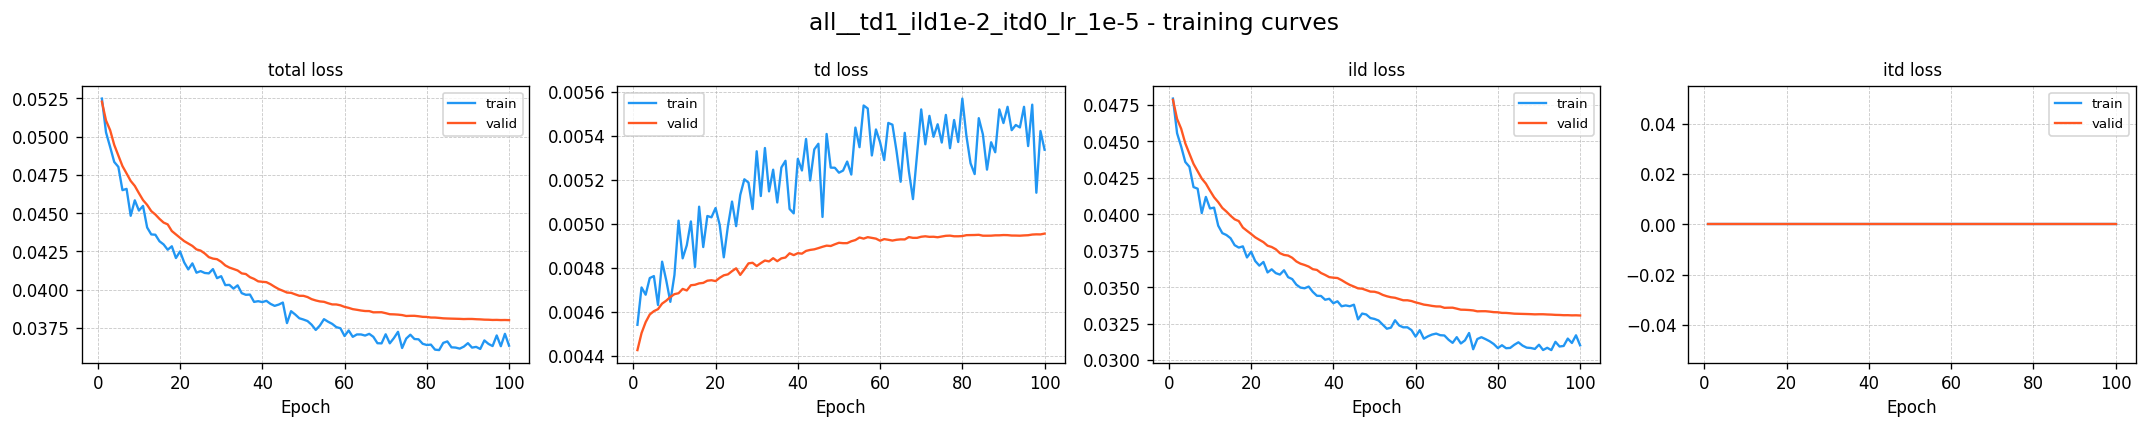

In [16]:
history = pd.read_csv(RUN_DIR / "history.csv")

fig, axes = plt.subplots(1, 4, figsize=(18, 3.6), dpi=120)
for ax, key in zip(axes, ["total", "td", "ild", "itd"]):
    ax.plot(history["epoch"], history[f"train_{key}"], color="#2196F3", lw=1.4, label="train")
    ax.plot(history["epoch"], history[f"valid_{key}"], color="#FF5722", lw=1.4, label="valid")
    ax.set_title(f"{key} loss", fontsize=10)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)
plt.suptitle(f"{RUN} - training curves", fontsize=14)
plt.tight_layout()
plt.show()

#best = history.loc[history["valid_total"].idxmin()]
#print(f"{len(history)} epochs, best valid loss = {best['valid_total']:.4f} @ epoch {int(best['epoch'])} "
      #f"(td={best['valid_td']:.4f}, ild={best['valid_ild']:.4f}, itd={best['valid_itd']:.4f})")

## Evaluation helpers

Each test track is separated **whole** (demucs `apply_model` handles the internal
overlapped chunking), then scored per source against the ground-truth stem:

- **SI-SDR** (dB) - separation quality.
- **Per-sub-band ILD MAE** (dB) - residual interaural **level**-difference error,
  averaged over time.
- **Per-sub-band ITD MAE** (samples, plotted in µs) - band-limited GCC-PHAT ITD
  error, same estimator as the training loss.
- **Per-sub-band IPD MAE** (rad) - wrapped phase error of the interaural
  cross-spectrum, weighted within each band by the target cross-power
  $|S_L||S_R|$; no peak picking.
- **Per-sub-band ΔIC** - error of the interaural coherence, estimated per band
  over `IC_FRAMES` frames.

Every band metric is first computed per band $k$ and STFT frame $t$, then
averaged over time, so each plotted curve is a function of frequency only.  The
time average runs over $\mathcal{T}_k$: with `FLOOR_DB` set, the audible frames
of band $k$ of the target (the mask depends on the target only, so both models
are scored on the same cells); with `FLOOR_DB = None`, all $T_f$ frames.

$$ \text{SI-SDR}(\hat{s}^{(s)}, s_{gt}^{(s)}) = 10 \cdot \log_{10} \left( \frac{\left\| \dfrac{\langle \hat{s}^{(s)}, s_{gt}^{(s)} \rangle}{\|s_{gt}^{(s)}\|^2} \cdot s_{gt}^{(s)} \right\|^2} {\left\| \hat{s}^{(s)} - \dfrac{\langle \hat{s}^{(s)}, s_{gt}^{(s)} \rangle}{\|s_{gt}^{(s)}\|^2} \cdot s_{gt}^{(s)} \right\|^2} \right) \quad \text{[dB]}$$
$$\mathcal{L}_{\text{ILD}}(k) = \frac{1}{|\mathcal{T}_k|}\sum_{t\in\mathcal{T}_k}\big|\overline{\mathrm{ILD}}(k,t) - \mathrm{ILD}_{gt}(k,t)\big|$$
$$\mathcal{L}_{\text{ITD}}(k) = \frac{1}{|\mathcal{T}_k|}\sum_{t\in\mathcal{T}_k}\big|\overline{\mathrm{ITD}}(k,t) - \mathrm{ITD}_{gt}(k,t)\big|$$
$$e_{\text{IPD}}(k,t) = \frac{\sum_{f\in k} |S_L S_R^*|\;\big|\angle\big(\hat{X}_L\hat{X}_R^*\,(S_L S_R^*)^*\big)\big|}{\sum_{f\in k} |S_L S_R^*|}, \qquad \mathcal{L}_{\text{IPD}}(k) = \frac{1}{|\mathcal{T}_k|}\sum_{t\in\mathcal{T}_k} e_{\text{IPD}}(k,t) \quad \text{[rad]}$$
$$\mathrm{IC}(k,t) = \frac{\big|\langle X_L X_R^*\rangle_{k,t}\big|}{\sqrt{\langle |X_L|^2\rangle_{k,t}\,\langle |X_R|^2\rangle_{k,t}}}, \qquad \Delta\mathrm{IC}(k) = \frac{1}{|\mathcal{T}_k|}\sum_{t\in\mathcal{T}_k}\big|\widehat{\mathrm{IC}}(k,t) - \mathrm{IC}_{gt}(k,t)\big|$$

In [5]:
def separate(net: torch.nn.Module, wav: torch.Tensor) -> torch.Tensor:
    """Run an HTDemucs model on a full (2, T) mix. Returns (S, 2, T)."""
    net.eval()
    return apply_model(net, wav.unsqueeze(0), shifts=SHIFTS,
                       progress=False).squeeze(0)

BAND_KW = dict(n_fft=EVAL["n_fft"], hop_length=EVAL["hop_length"], n_bands=EVAL["n_bands"],
               scale=EVAL["scale"], sample_rate=SAMPLE_RATE, floor_db=FLOOR_DB)

def band_metrics(est: torch.Tensor, tgt: torch.Tensor) -> dict:
    """All per-band spatial metrics of one stem; ITD/IPD/IC run on DEVICE."""
    est_d, tgt_d = est.to(DEVICE), tgt.to(DEVICE)
    return dict(
        ild_bands_mae=ild_bands_mae(est, tgt, **BAND_KW),
        itd_bands_mae=itd_bands_mae(est_d, tgt_d, **BAND_KW,
                                    max_lag=EVAL["max_lag"], beta=EVAL["beta"]),
        ipd_bands_mae=ipd_bands_mae(est_d, tgt_d, **BAND_KW),
        ic_bands_mae=ic_bands_mae(est_d, tgt_d, **BAND_KW, n_avg=IC_FRAMES),
    )

def evaluate_on_tracks(net, tracks, tag, out_dir: Optional[Path] = None) -> dict:
    """Separate every test track with `net` and collect per-source metrics."""
    print(f"Running {tag} on {len(tracks)} test tracks...")
    res = {}
    for idx, track_dir in enumerate(tracks, 1):
        mix_path = track_dir / "mixture.wav"
        if not mix_path.exists():
            print(f"[{idx}/{len(tracks)}] SKIP - no mixture.wav")
            continue
        print(f"[{idx}/{len(tracks)}] {track_dir.name} ...", end=" ", flush=True)
        t0 = time.perf_counter()

        wav   = load_audio(mix_path, SAMPLE_RATE).to(DEVICE)
        stems = separate(net, wav).cpu()   # (S, 2, T)

        if out_dir is not None:
            track_out_dir = out_dir / track_dir.name
            track_out_dir.mkdir(parents=True, exist_ok=True)
            for i, src in enumerate(SOURCES):
                torchaudio.save(str(track_out_dir / f"{src}.wav"), stems[i], SAMPLE_RATE)

        track_res = {}
        for i, src in enumerate(SOURCES):
            tgt_path = track_dir / f"{src}.wav"
            if not tgt_path.exists():
                continue
            tgt = load_audio(tgt_path, SAMPLE_RATE)
            est = stems[i]
            T   = min(tgt.shape[-1], est.shape[-1])
            tgt, est = tgt[:, :T], est[:, :T]

            track_res[src] = dict(si_sdr=si_sdr(est, tgt), **band_metrics(est, tgt))
        res[track_dir.name] = track_res
        print(f"done ({time.perf_counter() - t0:.1f}s)")

    print(f"{tag}: evaluation complete - {len(res)} tracks.\n")
    return res

# Collect the test tracks
test_dir = DATASET_ROOT / "test"
tracks = sorted((p for p in test_dir.iterdir() if p.is_dir()), key=lambda p: p.name.lower())
if LIMIT_TRACKS:
    tracks = tracks[:LIMIT_TRACKS]
print(f"Found {len(tracks)} test tracks.")

Found 50 test tracks.


## Separate the test set - baseline and fine-tune

The frozen pre-trained HTDemucs baseline and the fine-tune are run on the **same**
test tracks.  The checkpoint is loaded into a fresh HTDemucs - the freeze strategy
is irrelevant at inference time, the `model_state` already holds all weights.
Each model is released before the next one, so peak memory is that of a single
model.

The baseline metrics are **cached** under `RUNS_ROOT/baseline_metrics_test.json`
(a separate file from the `baseline_metrics.json` of `AblationHTDemucsSpatial`,
which computes a different metric set):
the frozen backbone gives the same numbers every session, so from the second
run on only the fine-tune is separated. The cache carries the band layout,
the metric set, the audibility floor, the dataset and the track list it was built with, and recomputes itself whenever
any of those changes (or when `USE_BASELINE_CACHE = False`).

In [6]:
def load_htdemucs(ckpt_path: Optional[Path] = None) -> torch.nn.Module:
    """Fresh HTDemucs; load a fine-tuned `model_state` when `ckpt_path` is given."""
    bag = get_model("htdemucs")
    net = bag.models[0] if hasattr(bag, "models") else bag
    net = net.to(DEVICE)
    if ckpt_path is not None:
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        net.load_state_dict(ckpt["model_state"])
        print(f"Loaded {ckpt_path.name}: best epoch {ckpt.get('epoch', '?')}, "
              f"valid loss {ckpt.get('valid_loss', float('nan')):.4f}")
    return net.eval()

results_by_model = {}   # label -> {track: {src: {si_sdr, *_bands_mae}}}

# -- Baseline: frozen pre-trained HTDemucs -------------------------------------
BASELINE_CACHE_PATH = RUNS_ROOT / "baseline_metrics_test.json"
_BAND_KEYS = ("ild_bands_mae", "itd_bands_mae", "ipd_bands_mae", "ic_bands_mae")

def _baseline_fingerprint() -> dict:
    return {"eval": EVAL, "dataset_root": str(DATASET_ROOT),
            "tracks": [t.name for t in tracks],
            "metrics": list(_BAND_KEYS), "floor_db": FLOOR_DB,
            "ic_frames": int(IC_FRAMES), "shifts": int(SHIFTS)}

def load_baseline_cache() -> Optional[dict]:
    """Cached baseline metrics, or None when absent, disabled or stale."""
    if not (USE_BASELINE_CACHE and BASELINE_CACHE_PATH.exists()):
        return None
    blob = json.loads(BASELINE_CACHE_PATH.read_text(encoding="utf-8"))
    if blob.get("fingerprint") != _baseline_fingerprint():
        print("Baseline cache is stale (band config, metrics, dataset or track list changed) "
              "- recomputing it.")
        return None
    # Per-band curves are stored as plain lists; bring them back as arrays.
    return {
        track: {src: {**m, **{k: np.asarray(m[k]) for k in _BAND_KEYS if k in m}}
                for src, m in track_res.items()}
        for track, track_res in blob["results"].items()
    }

def save_baseline_cache(res: dict) -> None:
    BASELINE_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    BASELINE_CACHE_PATH.write_text(json.dumps({
        "fingerprint": _baseline_fingerprint(),
        "results": {
            track: {src: {k: (v.tolist() if isinstance(v, np.ndarray) else v)
                          for k, v in m.items()}
                    for src, m in track_res.items()}
            for track, track_res in res.items()
        },
    }), encoding="utf-8")
    print(f"Baseline metrics cached to {BASELINE_CACHE_PATH}\n")

_cached = load_baseline_cache()
if _cached is not None:
    results_by_model[BASELINE_LABEL] = _cached
    print(f"{BASELINE_LABEL}: reusing cached metrics for {len(_cached)} tracks "
          f"({BASELINE_CACHE_PATH.name}) - set USE_BASELINE_CACHE = False to redo it.\n")
else:
    net = load_htdemucs(None)
    results_by_model[BASELINE_LABEL] = evaluate_on_tracks(net, tracks, tag=BASELINE_LABEL)
    save_baseline_cache(results_by_model[BASELINE_LABEL])
    del net
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

# -- Fine-tune -----------------------------------------------------------------
net = load_htdemucs(CKPT)
out_dir = (RUN_DIR / "estimates") if SAVE_ESTIMATES else None
results_by_model[RUN] = evaluate_on_tracks(net, tracks, tag=RUN, out_dir=out_dir)
if out_dir is not None:
    print(f"Estimates saved under {out_dir}")
del net
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Running htdemucs (baseline) on 50 test tracks...
[1/50] Al James - Schoolboy Facination ... done (14.0s)
[2/50] AM Contra - Heart Peripheral ... done (9.7s)
[3/50] Angels In Amplifiers - I'm Alright ... done (8.5s)
[4/50] Arise - Run Run Run ... done (10.4s)
[5/50] Ben Carrigan - We'll Talk About It All Tonight ... done (11.8s)
[6/50] BKS - Bulldozer ... done (15.7s)
[7/50] BKS - Too Much ... done (10.3s)
[8/50] Bobby Nobody - Stitch Up ... done (10.3s)
[9/50] Buitraker - Revo X ... done (13.0s)
[10/50] Carlos Gonzalez - A Place For Us ... done (11.7s)
[11/50] Cristina Vane - So Easy ... done (12.0s)
[12/50] Detsky Sad - Walkie Talkie ... done (9.0s)
[13/50] Enda Reilly - Cur An Long Ag Seol ... done (8.7s)
[14/50] Forkupines - Semantics ... done (12.8s)
[15/50] Georgia Wonder - Siren ... done (20.0s)
[16/50] Girls Under Glass - We Feel Alright ... done (14.8s)
[17/50] Hollow Ground - Ill Fate ... done (6.7s)
[18/50] James Elder & Mark M Thompson - The English Actor ... done (9.9s)
[19

## Summary - SI-SDR and ILD MAE per source

Per-source SI-SDR metric averaged over all test tracks, for the baseline and the fine-tune. The `All` row averages the four sources, and the `delta` columns are fine-tune minus baseline.

In [7]:
_METRIC_KEYS = ("si_sdr",) + _BAND_KEYS

def aggregate(res):
    ag = {src: {k: [] for k in _METRIC_KEYS} for src in SOURCES}
    for track_res in res.values():
        for src, m in track_res.items():
            for k in _METRIC_KEYS:
                ag[src][k].append(m[k])
    return ag

def per_source_table(ag) -> pd.DataFrame:
    """Means over tracks, per source (+ `All` row): SI-SDR and scalar ILD MAE."""
    df = pd.DataFrame({
        "SI-SDR (dB)":  {s: float(np.mean(ag[s]["si_sdr"]))                    for s in SOURCES},
    }).reindex(SOURCES)
    df.loc["All"] = df.mean(axis=0)
    return df

agg_by_model = {label: aggregate(res) for label, res in results_by_model.items()}

base_table = per_source_table(agg_by_model[BASELINE_LABEL])
run_table  = per_source_table(agg_by_model[RUN])

summary = pd.concat({BASELINE_LABEL: base_table, RUN: run_table}, axis=1)
summary[("delta", "dSI-SDR (dB)")]  = run_table["SI-SDR (dB)"]  - base_table["SI-SDR (dB)"]

print(f"{RUN} vs {BASELINE_LABEL} - {len(tracks)} test tracks\n")
with pd.option_context("display.float_format", lambda x: f"{x:+.3f}", "display.width", 200):
    print(summary)
summary

all__td1_ild1e-2_itd0_lr_1e-5 vs htdemucs (baseline) - 50 test tracks

       htdemucs (baseline) all__td1_ild1e-2_itd0_lr_1e-5        delta
               SI-SDR (dB)                   SI-SDR (dB) dSI-SDR (dB)
drums               +9.777                       +10.490       +0.713
bass                +7.096                       +10.838       +3.742
other               +4.277                        +5.996       +1.719
vocals              +7.883                        +8.753       +0.870
All                 +7.258                        +9.019       +1.761


,htdemucs (baseline),all__td1_ild1e-2_itd0_lr_1e-5,delta
,SI-SDR (dB),SI-SDR (dB),dSI-SDR (dB)
drums,9.777248,10.489907,0.712659
bass,7.096227,10.837961,3.741734
other,4.276771,5.996269,1.719498
vocals,7.882916,8.752773,0.869857
All,7.258291,9.019227,1.760937


## Summary - ΔIC per source

Interaural-coherence error per source, averaged over bands and test tracks, for
the baseline and the fine-tune (lower is better).  Same layout as the SI-SDR
table: the `All` row averages the four sources and the `delta` column is
fine-tune minus baseline, so a negative `dΔIC` means the fine-tune keeps the
spatial image of each stem more compact (less leakage from other directions).

**How the broadband ΔIC is computed.**  Let $X_L, X_R$ be the STFTs (Hann,
`n_fft`, `hop_length` of the run) of the two channels of a stem, $k$ a sub-band
(set of bins $f\in k$), $t$ an STFT frame and $N=$ `IC_FRAMES`.  The band
statistics are summed over the bins of the band and averaged over the $N$
frames centred on $t$, $W_t=\{t-\lfloor N/2\rfloor,\dots,t+\lfloor N/2\rfloor\}\cap[0,T_f)$:

$$\langle X_L X_R^*\rangle_{k,t} = \frac{1}{|W_t|}\sum_{\tau\in W_t}\sum_{f\in k} X_L(f,\tau)\,X_R^*(f,\tau), \qquad
\langle |X_c|^2\rangle_{k,t} = \frac{1}{|W_t|}\sum_{\tau\in W_t}\sum_{f\in k} |X_c(f,\tau)|^2,\quad c\in\{L,R\}$$

$$\mathrm{IC}(k,t) = \min\!\left(1,\; \frac{\big|\langle X_L X_R^*\rangle_{k,t}\big|}{\sqrt{\langle |X_L|^2\rangle_{k,t}\,\langle |X_R|^2\rangle_{k,t}}}\right)\in[0,1]$$

computed for the estimate ($\widehat{\mathrm{IC}}$, from $\hat{X}_{L,R}$) and for the
ground truth ($\mathrm{IC}_{gt}$, from $S_{L,R}$).  The per-band error is the
time average over the audible frames $\mathcal{T}_k$ of the target band
(power $P_k(t)=\frac{1}{|k|}\sum_{f\in k}|S_L|^2+|S_R|^2$ within `FLOOR_DB` of
its peak over time and above $-60$ dB; all frames when `FLOOR_DB = None`):

$$\Delta\mathrm{IC}(k) = \frac{1}{|\mathcal{T}_k|}\sum_{t\in\mathcal{T}_k}\big|\widehat{\mathrm{IC}}(k,t) - \mathrm{IC}_{gt}(k,t)\big| \qquad (\,0 \text{ if } \mathcal{T}_k=\varnothing\,)$$

The **broadband** value in the table for source $s$ is the plain mean over the
$K$ = `n_bands` bands and the $N_{tr}$ test tracks, and `All` / `dΔIC` follow:

$$\Delta\mathrm{IC}^{(s)} = \frac{1}{N}\sum_{n=1}^{N} \frac{1}{K}\sum_{k=1}^{K}\Delta\mathrm{IC}^{(s)}_n(k), \qquad
\Delta\mathrm{IC}^{\text{All}} = \frac{1}{4}\sum_{s}\Delta\mathrm{IC}^{(s)}, \qquad
d\Delta\mathrm{IC} = \Delta\mathrm{IC}_{\text{fine-tune}} - \Delta\mathrm{IC}_{\text{baseline}}$$

Note that this is the band-average of per-band errors, **not** the error of a
single IC computed over the whole spectrum: every band weighs $1/K$ regardless
of its energy, and a band with no audible frame contributes $0$.

In [8]:
def ic_table(ag) -> pd.DataFrame:
    """Means over tracks and bands, per source (+ `All` row): ΔIC."""
    df = pd.DataFrame({
        "ΔIC": {s: float(np.mean(ag[s]["ic_bands_mae"])) for s in SOURCES},
    }).reindex(SOURCES)
    df.loc["All"] = df.mean(axis=0)
    return df

base_ic = ic_table(agg_by_model[BASELINE_LABEL])
run_ic  = ic_table(agg_by_model[RUN])

ic_summary = pd.concat({BASELINE_LABEL: base_ic, RUN: run_ic}, axis=1)
ic_summary[("delta", "dΔIC")] = run_ic["ΔIC"] - base_ic["ΔIC"]

print(f"{RUN} vs {BASELINE_LABEL} - {len(tracks)} test tracks\n")
with pd.option_context("display.float_format", lambda x: f"{x:+.4f}", "display.width", 200):
    print(ic_summary)
ic_summary


all__td1_ild1e-2_itd0_lr_1e-5 vs htdemucs (baseline) - 50 test tracks

       htdemucs (baseline) all__td1_ild1e-2_itd0_lr_1e-5   delta
                       ΔIC                           ΔIC    dΔIC
drums              +0.2824                       +0.2889 +0.0065
bass               +0.3300                       +0.3179 -0.0121
other              +0.3071                       +0.2937 -0.0133
vocals             +0.2668                       +0.2504 -0.0164
All                +0.2966                       +0.2877 -0.0088


,htdemucs (baseline),all__td1_ild1e-2_itd0_lr_1e-5,delta
,ΔIC,ΔIC,dΔIC
drums,0.282416,0.288944,0.006529
bass,0.329993,0.317874,-0.012119
other,0.307076,0.293746,-0.013330
vocals,0.266754,0.250377,-0.016377
All,0.296560,0.287735,-0.008824


## Track ranking by SI-SDR

Per-track SI-SDR of one model, one column per source; the `mean` column averages
the four sources.  Tracks go from the highest SI-SDR (the **best**) to the lowest
(the **worst**).  The `d<source>` columns are the same model minus the baseline
on that track, so a good average can be told apart from a few large gains that
hide per-track regressions.  `RANK_LABEL` selects the ranked model and `RANK_BY`
the sorting column (`"mean"` or a single source, e.g. `"other"`).

In [9]:
RANK_LABEL = RUN
RANK_BY    = "mean"

def si_sdr_per_track(res) -> pd.DataFrame:
    """Per-track SI-SDR (dB), one column per source plus their `mean`."""
    rows = {}
    for track_name, track_res in res.items():
        per_src = {src: track_res[src]["si_sdr"] for src in SOURCES if src in track_res}
        if not per_src:
            continue
        per_src["mean"] = float(np.mean(list(per_src.values())))
        rows[track_name] = per_src
    return pd.DataFrame.from_dict(rows, orient="index", columns=SOURCES + ["mean"])

rank_df = si_sdr_per_track(results_by_model[RANK_LABEL])
if RANK_LABEL != BASELINE_LABEL:
    delta = rank_df - si_sdr_per_track(results_by_model[BASELINE_LABEL]).reindex(rank_df.index)
    rank_df = rank_df.join(delta.add_prefix("d"))
si_sdr_ranking = rank_df.sort_values(RANK_BY, ascending=False)
si_sdr_ranking.index.name = "track"

print(f"SI-SDR (dB) per track for {RANK_LABEL!r} - ranked best -> worst by {RANK_BY!r}")
with pd.option_context("display.max_rows", None, "display.width", 250,
                       "display.float_format", lambda x: f"{x:+7.2f}"):
    print(si_sdr_ranking)
print(f"Best:  {si_sdr_ranking.index[0]}  ({si_sdr_ranking[RANK_BY].iloc[0]:+.2f} dB)")
print(f"Worst: {si_sdr_ranking.index[-1]}  ({si_sdr_ranking[RANK_BY].iloc[-1]:+.2f} dB)")
si_sdr_ranking

SI-SDR (dB) per track for 'all__td1_ild1e-2_itd0_lr_1e-5' - ranked best -> worst by 'mean'
                                                    drums    bass   other  vocals    mean  ddrums   dbass  dother  dvocals   dmean
track                                                                                                                             
Enda Reilly - Cur An Long Ag Seol                  +14.96  +15.66  +10.24  +12.59  +13.36   +0.60   +5.08   +2.65    -0.42   +1.98
Little Chicago's Finest - My Own                   +14.73  +17.93   +4.73  +14.51  +12.98   +0.58   -0.54   +0.37    +0.52   +0.23
The Long Wait - Dark Horses                        +11.85  +12.72  +12.45  +12.67  +12.42   +2.55   +3.44   +4.22    +1.28   +2.87
Secretariat - Over The Top                         +12.03  +14.90   +8.89  +11.61  +11.86   +2.22   +2.70   +0.95    +1.19   +1.76
Sambasevam Shanmugam - Kaathaadi                   +10.43  +12.08  +10.63  +14.27  +11.85   +3.86   +3.32   +3.37    -0.31 

,drums,bass,other,vocals,mean,ddrums,dbass,dother,dvocals,dmean
track,,,,,,,,,,
Enda Reilly - Cur An Long Ag Seol,14.955291,15.659212,10.244299,12.591114,13.362479,0.597582,5.084425,2.650836,-0.415617,1.979306
Little Chicago's Finest - My Own,14.729652,17.932622,4.732877,14.510175,12.976332,0.580578,-0.538286,0.366498,0.521097,0.232472
The Long Wait - Dark Horses,11.846396,12.722015,12.451254,12.667674,12.421835,2.552899,3.438626,4.216499,1.279851,2.871969
Secretariat - Over The Top,12.033597,14.895883,8.889818,11.613404,11.858175,2.219939,2.697080,0.945259,1.192622,1.763725
Sambasevam Shanmugam - Kaathaadi,10.431210,12.079127,10.627733,14.272281,11.852588,3.860038,3.316503,3.369688,-0.306715,2.559879
Motor Tapes - Shore,11.412071,12.418747,12.117445,11.005440,11.738426,2.394794,2.027450,0.776242,1.362962,1.640362
Speak Softly - Like Horses,8.083752,21.163177,8.835607,8.794940,11.719369,-0.982826,0.449004,1.637944,1.533217,0.659335
Punkdisco - Oral Hygiene,14.575486,15.772470,5.188466,10.589733,11.531539,2.774119,4.827328,4.733352,0.868776,3.300894
Louis Cressy Band - Good Time,11.122898,11.950302,11.153561,10.469108,11.173967,2.882365,2.618139,3.092986,1.255742,2.462308


## Per-band ILD MAE - fine-tune vs baseline

One panel per source; each curve is a model's mean per-band ILD MAE over the test
set, i.e. for band $k$ and source $s$:

$$  \mathcal{L}_{\text{ILD}}(k)^{(s)} = \frac{1}{N} \sum_{n=1}^{N} \mathcal{L}_{\text{ILD}_{n}}(k)^{(s)}\quad\text{[dB]}$$

The fine-tune preserves the level cue better than the baseline where its curve
sits **below** the baseline curve.

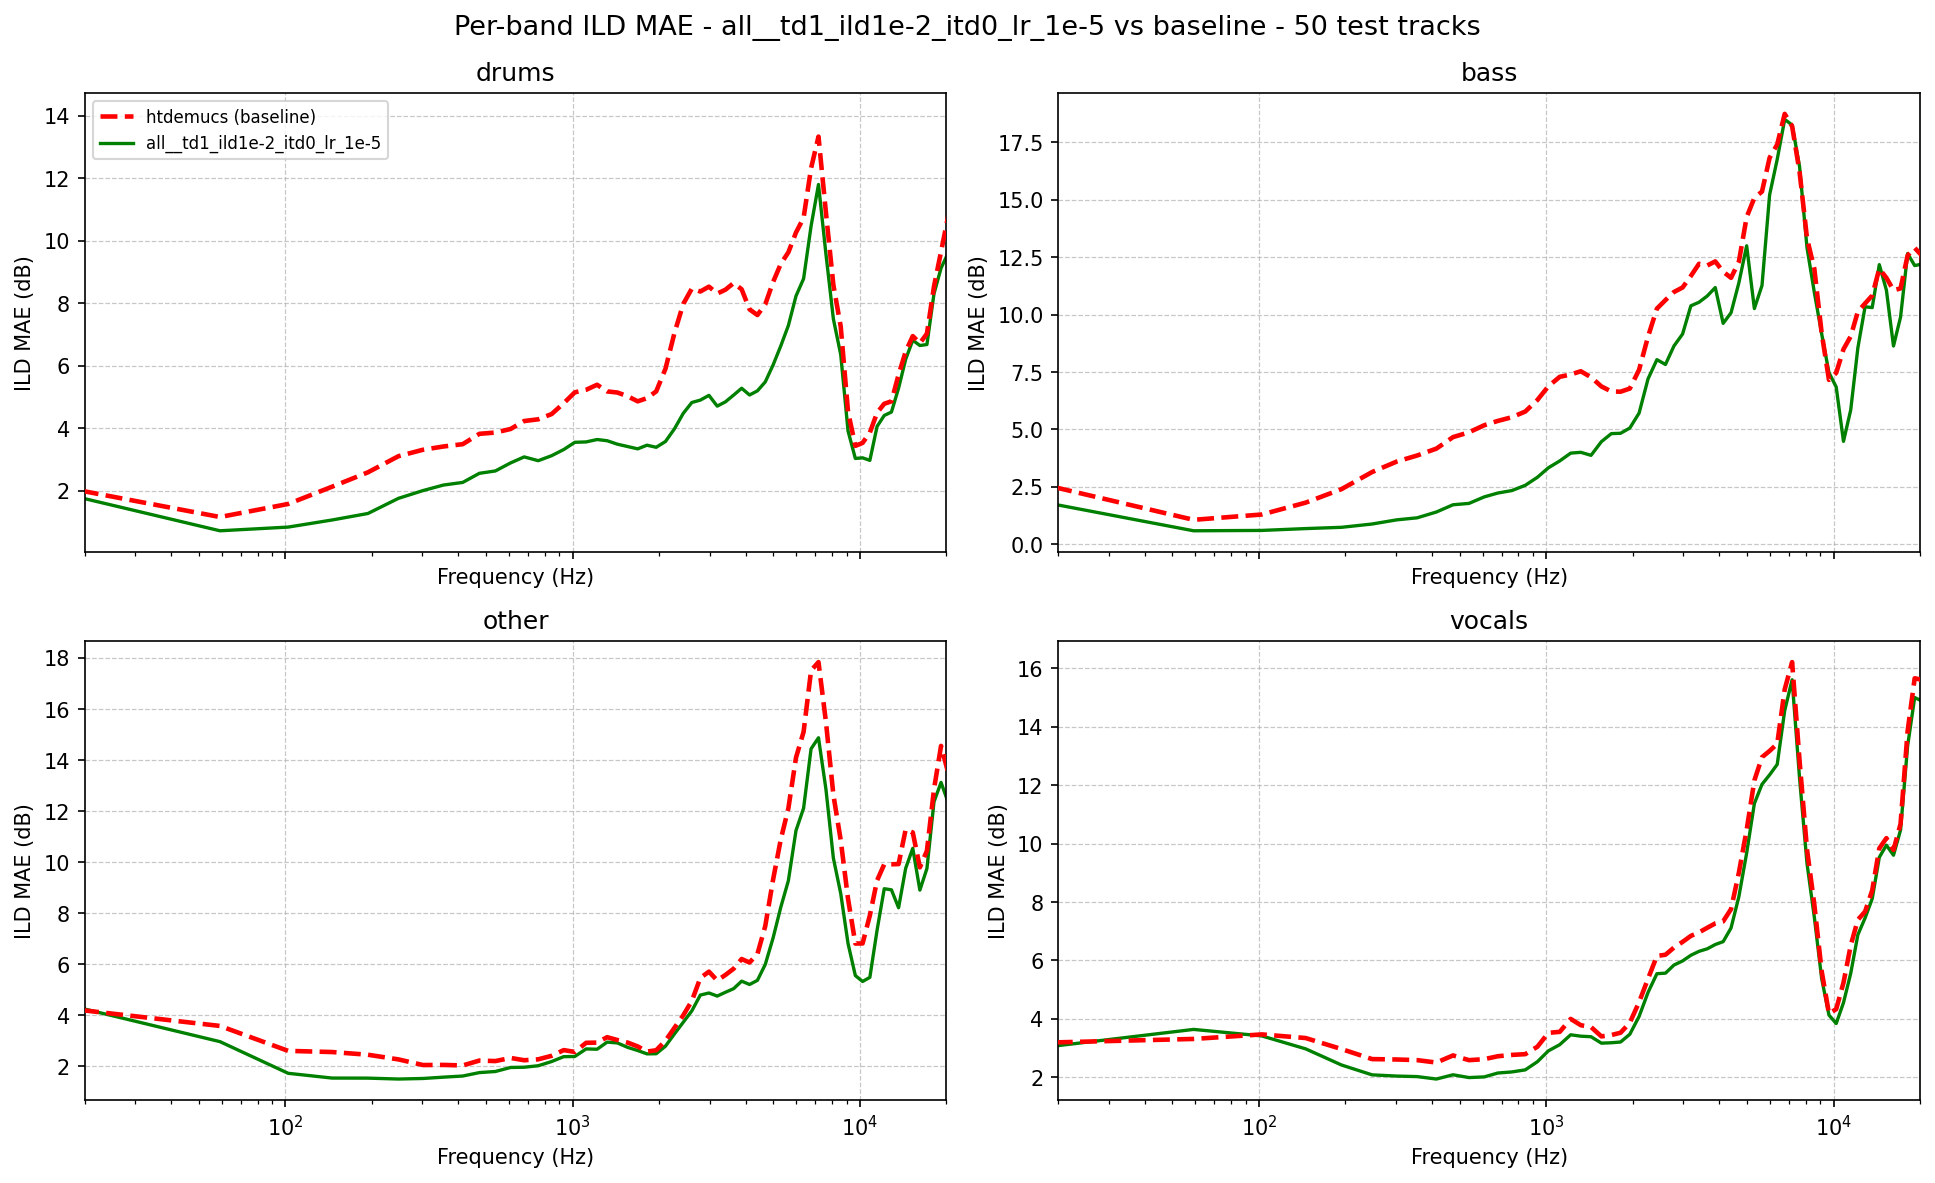

In [13]:
# Band centre frequencies (x-axis): mean Hz per Mel band, or linear midpoints.
n_bands = EVAL["n_bands"]
if EVAL["scale"] == "mel":
    _ba     = mel_bin_assignment(int(EVAL["n_fft"]), n_bands, int(SAMPLE_RATE))
    _bin_hz = np.arange(int(EVAL["n_fft"]) // 2 + 1) * (int(SAMPLE_RATE) / int(EVAL["n_fft"]))
    band_hz = np.array([
        _bin_hz[(_ba == m).numpy()].mean() if (_ba == m).any() else 0.0
        for m in range(n_bands)
    ])
else:
    band_hz = np.linspace(0, SAMPLE_RATE / 2, n_bands, endpoint=False)

def mean_bands(ag, src, key):
    return np.mean(ag[src][key], axis=0)   # (n_bands,)

_STYLES = {
    BASELINE_LABEL: dict(color="red",   lw=2.2, ls="--", zorder=3),
    RUN:            dict(color="green", lw=1.6, ls="-"),
}
PHASE_LIMIT_HZ = 1500   # above it the interaural phase is ambiguous

def plot_band_metric(key: str, ylabel: str, name: str, factor: float = 1.0,
                     phase_limit: bool = False) -> None:
    """One panel per source: per-band `key` of baseline vs fine-tune, times `factor`."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=150, sharex=True)
    for ax, src in zip(axes.ravel(), SOURCES):
        for label, style in _STYLES.items():
            ag = agg_by_model[label]
            if not ag[src][key]:
                continue
            ax.plot(band_hz, factor * mean_bands(ag, src, key), label=label, **style)
        if phase_limit:
            ax.axvline(PHASE_LIMIT_HZ, color="gray", lw=1.0, ls=":",
                       label=f"{PHASE_LIMIT_HZ / 1000:g} kHz")
        ax.set_xscale("log")
        ax.set_xlim(20, 20000)
        ax.set_title(src)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
        ax.set_axisbelow(True)
    axes.ravel()[0].legend(fontsize=8, loc="best")
    fig.suptitle(f"Per-band {name} - {RUN} vs baseline - {len(tracks)} test tracks", fontsize=13)
    plt.tight_layout()
    plt.show()

plot_band_metric("ild_bands_mae", "ILD MAE (dB)", "ILD MAE")

## Per-band ITD MAE - fine-tune vs baseline

Same layout as the ILD plot, for the band-limited GCC-PHAT ITD error, converted
from samples to µs:

$$  \mathcal{L}_{\text{ITD}}(k)^{(s)} = \frac{10^6}{f_s}\,\frac{1}{N} \sum_{n=1}^{N} \mathcal{L}_{\text{ITD}_{n}}(k)^{(s)}\quad\text{[µs]}$$

The dotted line marks ~1.5 kHz: above it the band-limited cross-correlation has
several peaks within `±max_lag`, so the ITD estimate (and its error) is no longer
a reliable localisation cue.


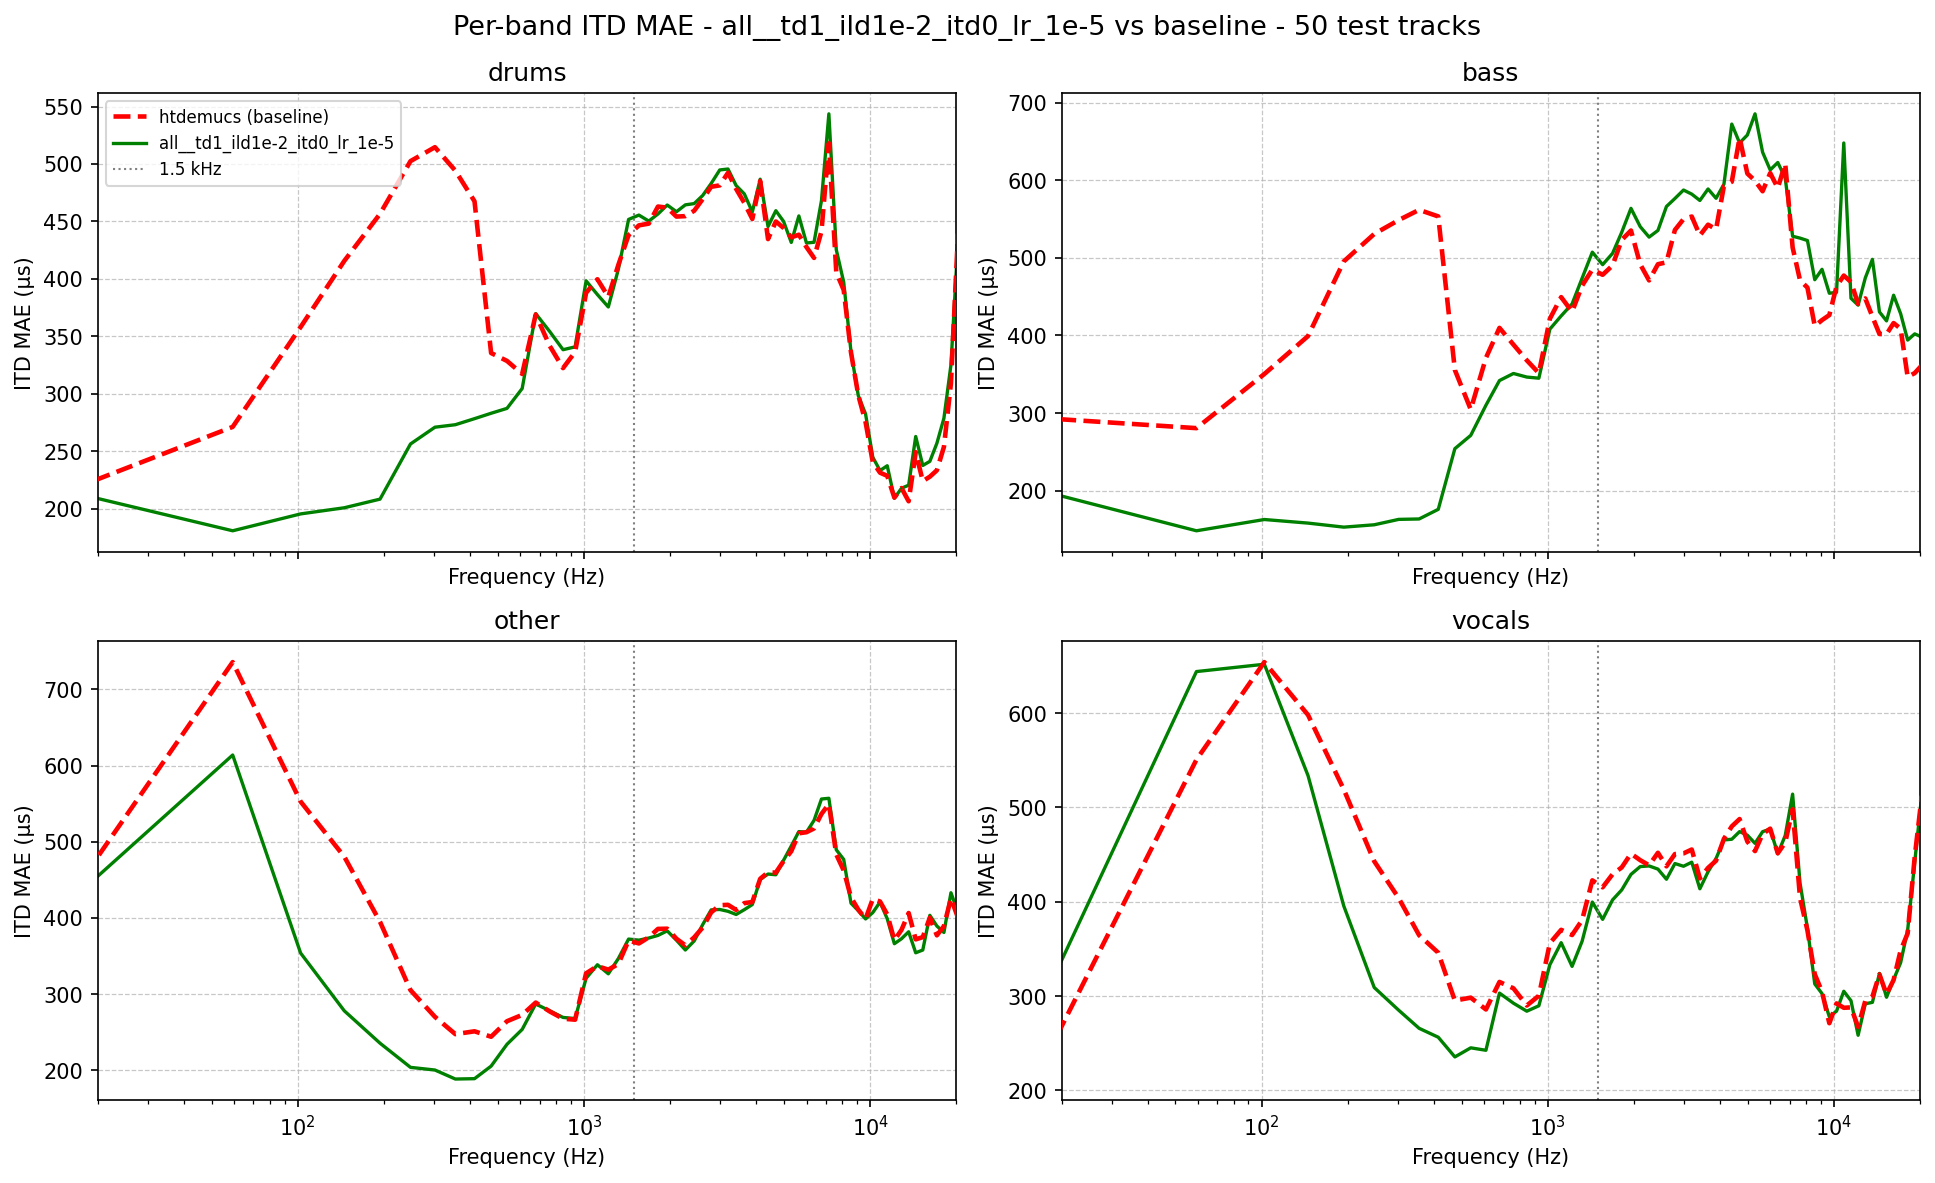

In [14]:
plot_band_metric("itd_bands_mae", "ITD MAE (µs)", "ITD MAE",
                 factor=1e6 / SAMPLE_RATE, phase_limit=True)


## Per-band IPD MAE - fine-tune vs baseline

Same layout, for the interaural phase-difference error in radians.  It needs no
peak picking, so it is a more robust view of the time cue than the ITD MAE.
$\pi/2$ is the error of an uncorrelated (random-phase) estimate; below ~1.5 kHz
the curve maps directly to an ITD error.

$$  \mathcal{L}_{\text{IPD}}(k)^{(s)} = \frac{1}{N} \sum_{n=1}^{N} \mathcal{L}_{\text{IPD}_{n}}(k)^{(s)}\quad\text{[rad]}$$


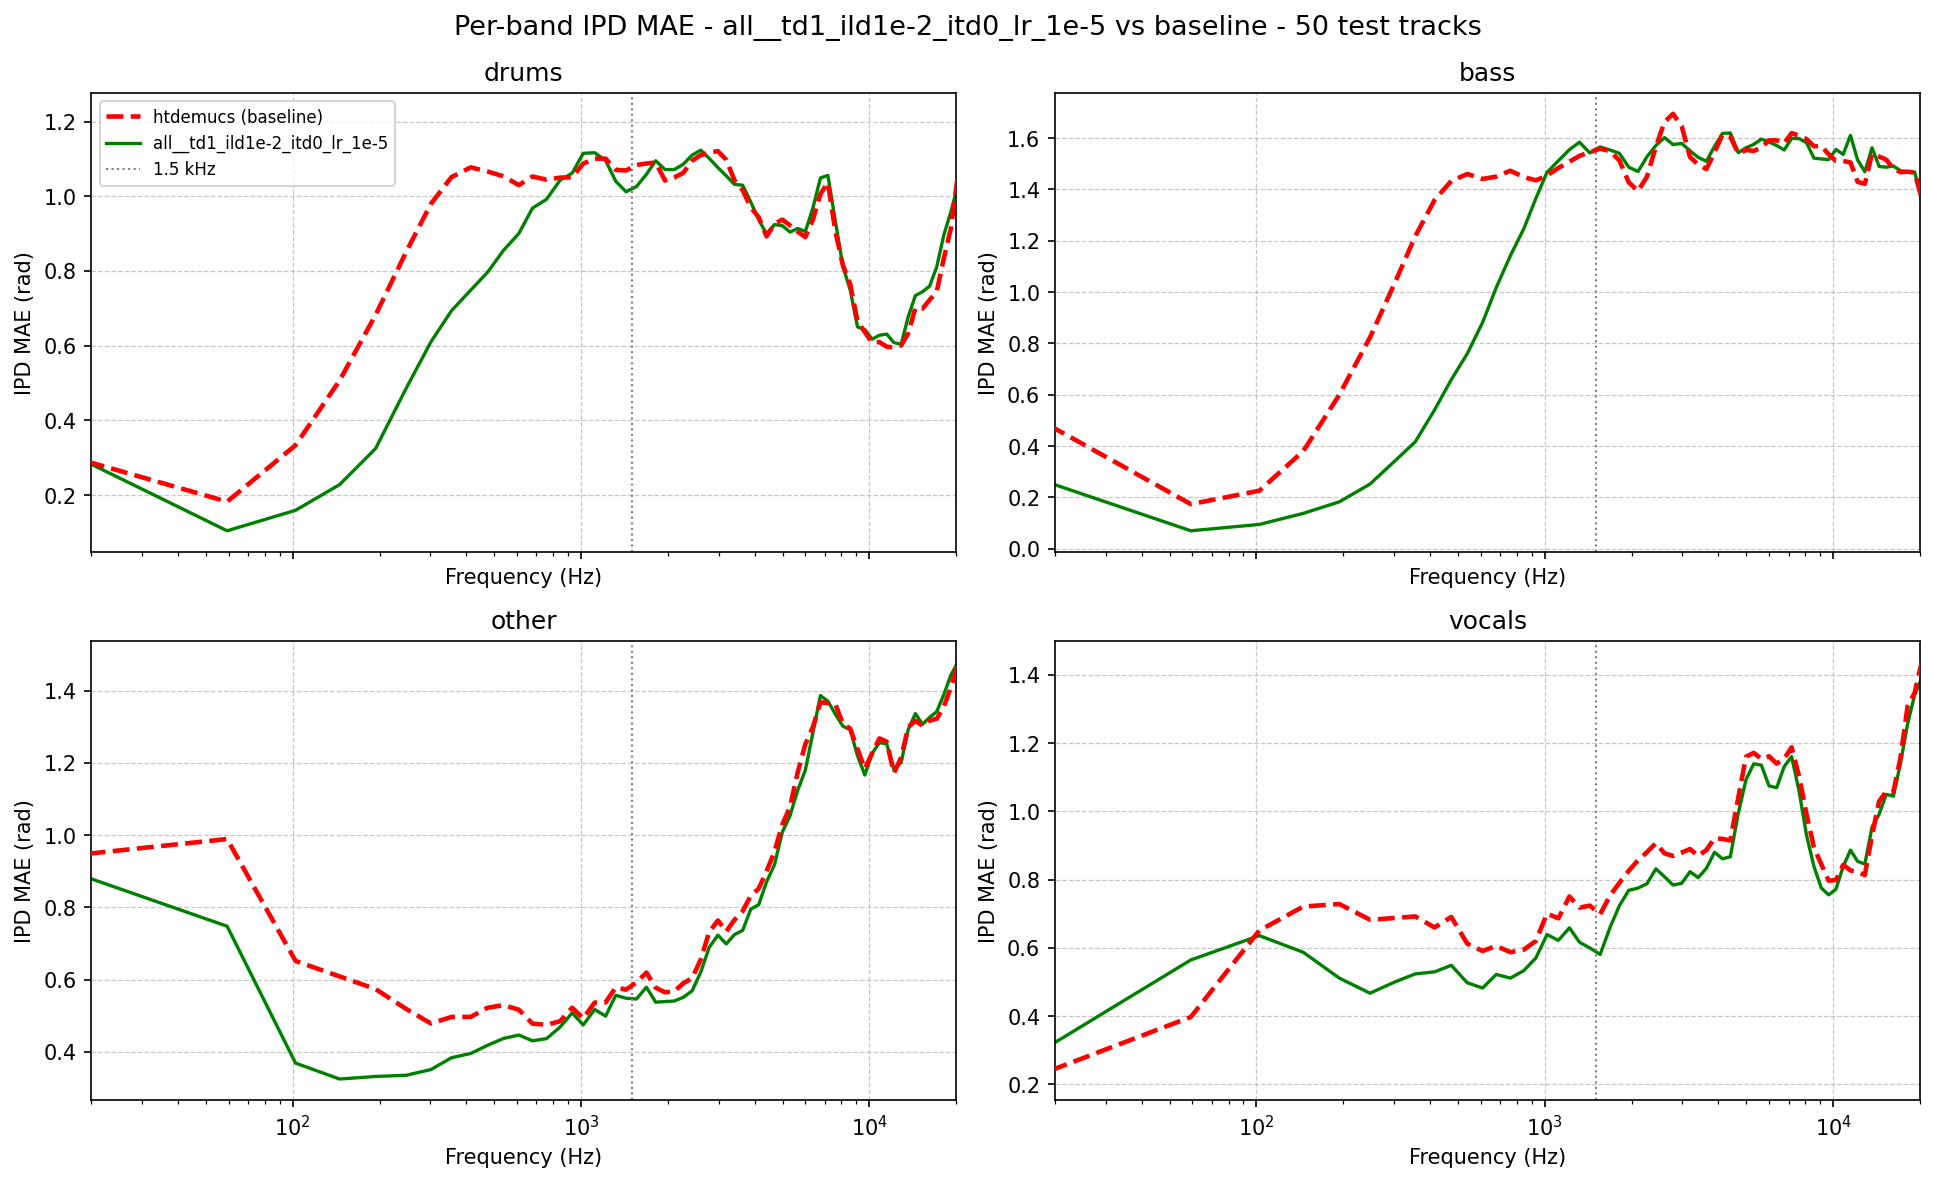

In [15]:
plot_band_metric("ipd_bands_mae", "IPD MAE (rad)", "IPD MAE", phase_limit=True)
